# Actividad 3. Reducción de dimensionalidad y clustering 

## Dataset utilizado: Human Activity Recognition Using Smartphones  
### Link de descarga: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

### Alumna: Tatiana Duran - a2521

#### Human Activity Recognition Using Smartphones (UCI). 

Participaron 30 voluntarios de 19 a 48 años. Cada uno hizo 6 actividades con un Samsung Galaxy S II en la cintura: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING. El acelerómetro y el giroscopio del celular registraron señales en 3 ejes a 50 Hz.

Cada observación es una ventana de 2.56 s de señal (128 lecturas, con 50 % de solapamiento) de un sujeto haciendo una actividad. De cada ventana se calcularon 561 features en el dominio del tiempo y de la frecuencia: media, desvío, máximo, energía, entropía, coeficientes de la FFT, etc. En total hay 10299 ventanas: 7352 de train y 2947 de test, con sujetos distintos en cada partición.

## Descarga del dataset, análisis exploratorio y preprocesamiento

In [1]:
import io, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


url = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
outer = zipfile.ZipFile(io.BytesIO(urllib.request.urlopen(url).read()))
inner = zipfile.ZipFile(io.BytesIO(outer.read("UCI HAR Dataset.zip")))
inner.extractall(".")   # crea la carpeta "UCI HAR Dataset/"

base = "UCI HAR Dataset/"
features = pd.read_csv(base + "features.txt", sep=r"\s+", header=None, names=["idx", "name"])

# Hay nombres de features repetidos: los hacemos únicos
names = features["name"].copy()
dup = names.duplicated(keep=False)
names[dup] = names[dup] + "_" + features.loc[dup, "idx"].astype(str)

act_labels = pd.read_csv(base + "activity_labels.txt", sep=r"\s+", header=None,
                         index_col=0).squeeze().to_dict()

def load(split):
    X = pd.read_csv(base + f"{split}/X_{split}.txt", sep=r"\s+", header=None, names=names)
    y = pd.read_csv(base + f"{split}/y_{split}.txt", header=None)[0].map(act_labels)
    s = pd.read_csv(base + f"{split}/subject_{split}.txt", header=None)[0]
    return X, y, s

X_tr, y_tr, s_tr = load("train")
X_te, y_te, s_te = load("test")

# Para clustering/reducción de dimensionalidad no hace falta separar train/test
X = pd.concat([X_tr, X_te], ignore_index=True)
y = pd.concat([y_tr, y_te], ignore_index=True)
subject = pd.concat([s_tr, s_te], ignore_index=True)
print(X.shape)


(10299, 561)


In [3]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10299 entries, 0 to 10298
Columns: 561 entries, tBodyAcc-mean()-X to angle(Z,gravityMean)
dtypes: float64(561)
memory usage: 44.1 MB


float64    561
Name: count, dtype: int64
     min  max
min -1.0  1.0
max -1.0  1.0


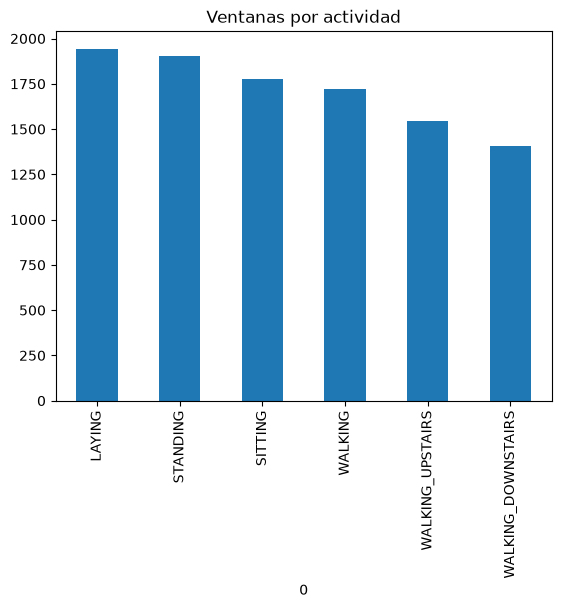

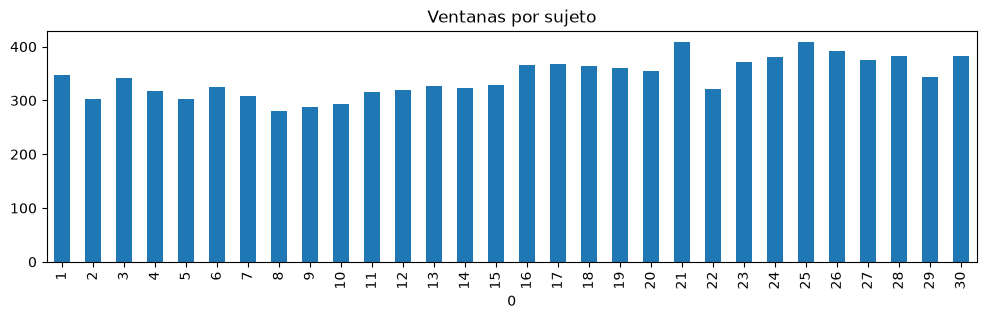

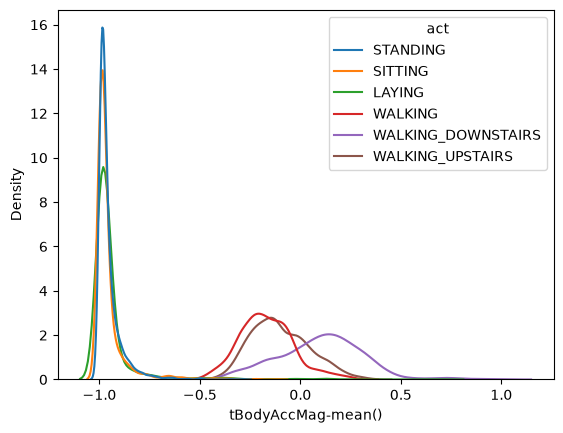

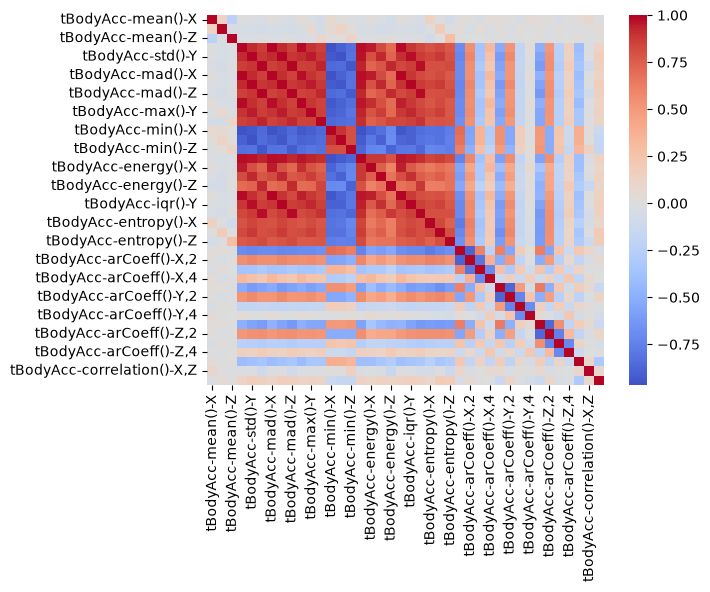

In [4]:
print(X.dtypes.value_counts())          # todas float64
print(X.describe().T[['min', 'max']].agg(['min', 'max']))  # ya están en [-1, 1]

# Distribución de clases
y.value_counts().plot(kind='bar'); plt.title('Ventanas por actividad'); plt.show()

# Ventanas por sujeto
subject.value_counts().sort_index().plot(kind='bar', figsize=(12, 3))
plt.title('Ventanas por sujeto'); plt.show()

# Ejemplo: una feature separa actividades estáticas vs dinámicas
sns.kdeplot(data=X.assign(act=y), x='tBodyAccMag-mean()', hue='act', common_norm=False)
plt.show()

# Correlación de un subconjunto (hay mucha redundancia → justifica PCA)
sns.heatmap(X.iloc[:, :40].corr(), cmap='coolwarm', center=0); plt.show()


In [5]:
from sklearn.preprocessing import StandardScaler

print("Faltantes:", X.isna().sum().sum())      # 0
print("Duplicados:", X.duplicated().sum())

X_scaled = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)


Faltantes: 0
Duplicados: 0


In [6]:
X.shape

(10299, 561)

## Reducción de dimensionalidad y clustering

### PCA

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(10299, 100)

In [8]:
# varianza explicada por cada componente
explained_var = pca.explained_variance_ratio_

# varianza acumulada
cumulative_var = np.cumsum(explained_var)

# varianza total
total_var = explained_var.sum()

n_components = len(explained_var)
componentes = np.arange(1, n_components + 1)

In [9]:
print(f'Varianza explicada por cada componente:\n{explained_var}')

Varianza explicada por cada componente:
[0.50738221 0.06239186 0.02692564 0.02452871 0.01888936 0.01631395
 0.01414533 0.01216211 0.00985248 0.00949228 0.00858304 0.0080998
 0.00765863 0.00676668 0.00630242 0.00615718 0.00595335 0.00577195
 0.00563431 0.0054083  0.00518828 0.00502742 0.00473229 0.00463818
 0.00446848 0.00439868 0.00416863 0.00400809 0.00389072 0.00381339
 0.0036687  0.00364357 0.00349225 0.00346736 0.00335539 0.00329411
 0.00323824 0.00300508 0.00294254 0.00290452 0.00275765 0.00269864
 0.00264196 0.0025803  0.00255031 0.00247776 0.00245537 0.0023829
 0.00235902 0.00232044 0.0022836  0.00219182 0.00212631 0.00209145
 0.0020348  0.00201167 0.00198111 0.00194391 0.00192509 0.00189539
 0.00186403 0.00182923 0.00180956 0.00176364 0.00174188 0.00171471
 0.00171041 0.00167453 0.00163703 0.00161446 0.00160293 0.00156591
 0.00150233 0.00148803 0.00148602 0.00144989 0.00144415 0.00142142
 0.0014083  0.00137123 0.00133349 0.00132868 0.0013115  0.00128449
 0.00127411 0.00124424 0

In [10]:
print(f'Varianza total:\n{total_var}')

Varianza total:
0.9467114549071656


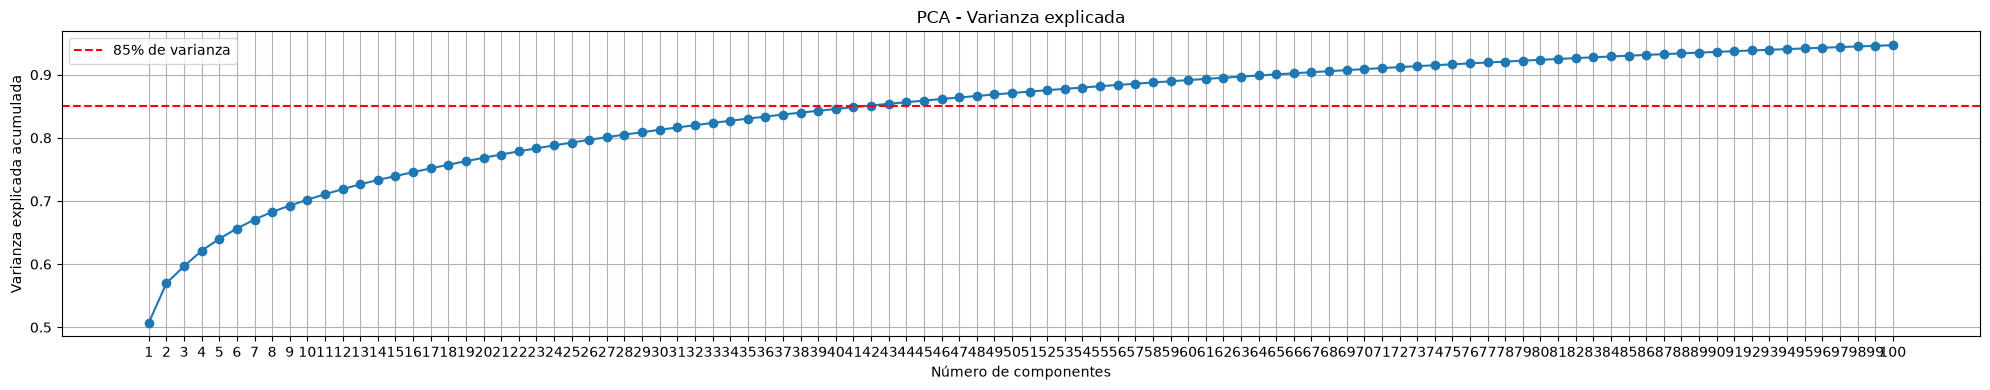

Varianza explicada acumulada:
[0.50738221 0.56977407 0.59669971 0.62122842 0.64011777 0.65643173
 0.67057706 0.68273917 0.69259164 0.70208392 0.71066696 0.71876676
 0.72642539 0.73319206 0.73949448 0.74565165 0.751605   0.75737696
 0.76301127 0.76841957 0.77360785 0.77863527 0.78336756 0.78800575
 0.79247423 0.79687291 0.80104154 0.80504963 0.80894035 0.81275373
 0.81642243 0.82006601 0.82355825 0.82702561 0.830381   0.83367511
 0.83691335 0.83991843 0.84286097 0.84576549 0.84852314 0.85122179
 0.85386374 0.85644405 0.85899435 0.86147211 0.86392749 0.86631039
 0.86866941 0.87098985 0.87327345 0.87546527 0.87759158 0.87968303
 0.88171782 0.88372949 0.8857106  0.88765451 0.8895796  0.89147499
 0.89333902 0.89516825 0.89697782 0.89874146 0.90048333 0.90219804
 0.90390845 0.90558298 0.90722001 0.90883447 0.9104374  0.9120033
 0.91350564 0.91499366 0.91647968 0.91792957 0.91937372 0.92079514
 0.92220344 0.92357467 0.92490816 0.92623684 0.92754834 0.92883283
 0.93010695 0.93135118 0.9325653 

In [11]:
plt.figure(figsize=(20, 4))
plt.plot(componentes, cumulative_var, marker='o')
plt.xticks(componentes)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA - Varianza explicada')
plt.grid(True)
plt.axhline(y=0.85, color='red', linestyle='--', label='85% de varianza')
plt.tight_layout()
plt.legend()
plt.show()

print(f'Varianza explicada acumulada:\n{cumulative_var}')

## UMAP

In [ ]:
umap_model = umap.UMAP(
    n_components=2,
    n_jobs=1,
    n_neighbors=18,
    min_dist=0.1,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)

MemoryError: Allocation failed (probably too large).

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=30,
    alpha=0.7
)

plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.title("UMAP - Dataset de Human Activity Recognition")

plt.grid(
    color="lightgray",
    linestyle="--",
    linewidth=0.6
)

plt.tight_layout()
plt.show()